In [ ]:
from google.colab import drive
drive.mount('/content/drive')

2.1 Exercise - 1:

1️ Read and Display Image

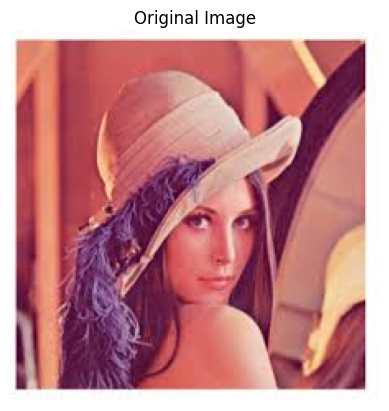

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# Load image
image = Image.open("Lena.png")

# Convert to numpy
image_array = np.array(image)

# Display image
plt.imshow(image_array)
plt.title("Original Image")
plt.axis("off")
plt.show()

2 Display Top-Left 100×100 Pixels

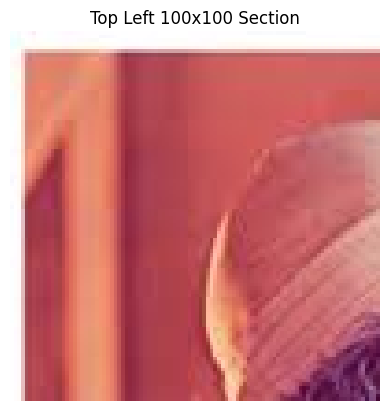

In [2]:
# Extract top-left 100x100 pixels
top_left = image_array[0:100, 0:100]

plt.imshow(top_left)
plt.title("Top Left 100x100 Section")
plt.axis("off")
plt.show()

3 Show R, G, B Channels (NumPy)

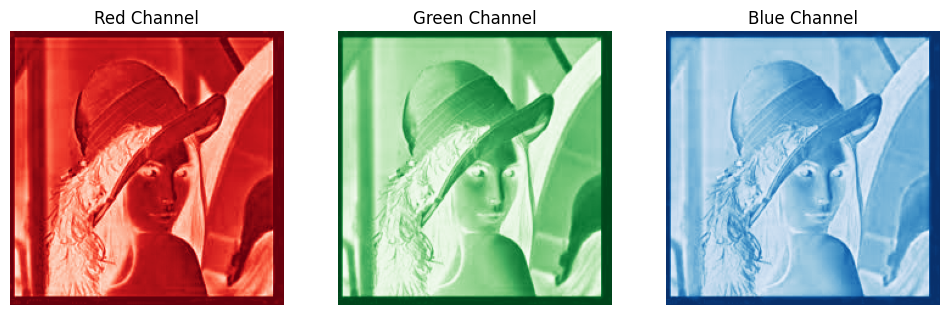

In [3]:
# Extract channels
red = image_array[:,:,0]
green = image_array[:,:,1]
blue = image_array[:,:,2]

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(red, cmap="Reds")
plt.title("Red Channel")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(green, cmap="Greens")
plt.title("Green Channel")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(blue, cmap="Blues")
plt.title("Blue Channel")
plt.axis("off")

plt.show()

4 Modify Top-Left 100×100 Pixels to 210

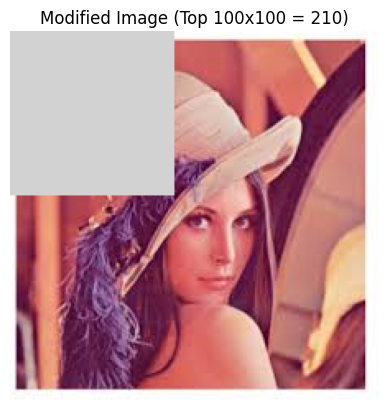

In [4]:

modified = image_array.copy()

# Modify pixels
modified[0:100,0:100] = 210

plt.imshow(modified)
plt.title("Modified Image (Top 100x100 = 210)")
plt.axis("off")
plt.show()

2.2 Exercise - 2:

1 Load and Display Grayscale Image

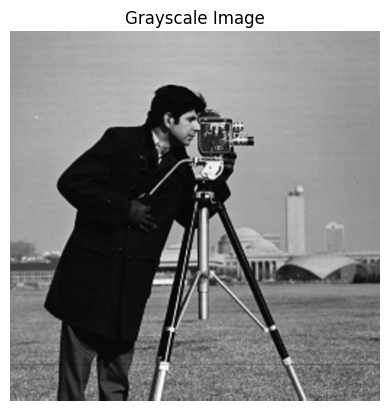

In [5]:
# Load grayscale image
gray_image = Image.open("cameraman.png").convert("L")

gray_array = np.array(gray_image)

plt.imshow(gray_array, cmap="gray")
plt.title("Grayscale Image")
plt.axis("off")
plt.show()

2 Extract Middle 150 Pixels

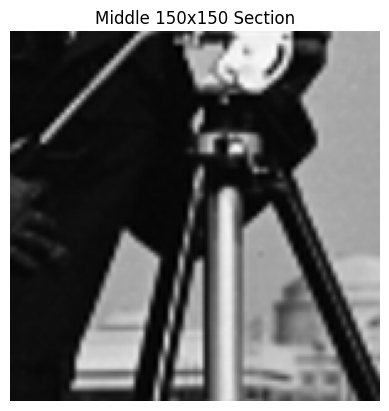

In [6]:
h, w = gray_array.shape

# center region
middle = gray_array[h//2-75:h//2+75, w//2-75:w//2+75]

plt.imshow(middle, cmap="gray")
plt.title("Middle 150x150 Section")
plt.axis("off")
plt.show()

3 Apply Threshold

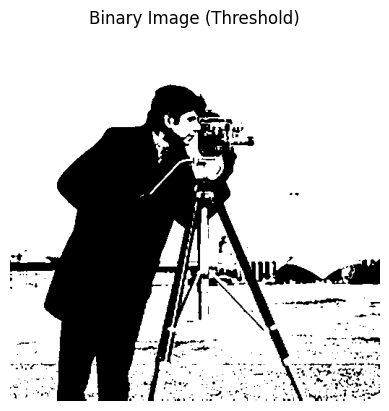

In [7]:
binary = gray_array.copy()

binary[binary < 100] = 0
binary[binary >= 100] = 255

plt.imshow(binary, cmap="gray")
plt.title("Binary Image (Threshold)")
plt.axis("off")
plt.show()

4 Rotate Image 90° Clockwise

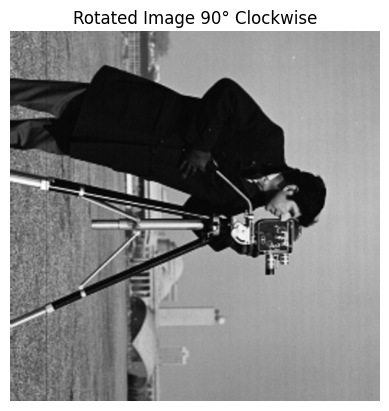

In [8]:
rotated = np.rot90(gray_array, -1)

plt.imshow(rotated, cmap="gray")
plt.title("Rotated Image 90° Clockwise")
plt.axis("off")
plt.show()

5 Convert Grayscale to RGB

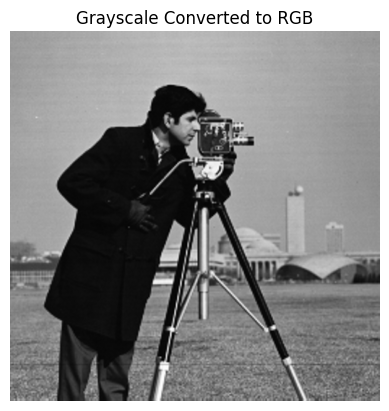

In [9]:
rgb_image = np.stack((gray_array,)*3, axis=-1)

plt.imshow(rgb_image)
plt.title("Grayscale Converted to RGB")
plt.axis("off")
plt.show()

3 Image Compression and Decompression using PCA.
1 Load and Prepare Data

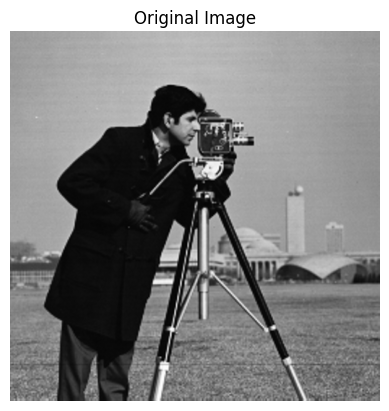

In [10]:
image = Image.open("cameraman.png").convert("L")

image_array = np.array(image)

height, width = image_array.shape

data = image_array.reshape(height, width)

plt.imshow(image_array, cmap="gray")
plt.title("Original Image")
plt.axis("off")
plt.show()

Standardize Data

In [11]:
mean = np.mean(data, axis=0)

centered_data = data - mean

Covariance Matrix

In [13]:
cov_matrix = np.cov(centered_data, rowvar=False)

2. Eigen Decomposition and Identifying Principal Components

In [14]:
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)

sorted_index = np.argsort(eigenvalues)[::-1]

eigenvalues = eigenvalues[sorted_index]

eigenvectors = eigenvectors[:, sorted_index]

Explained Variance Plot

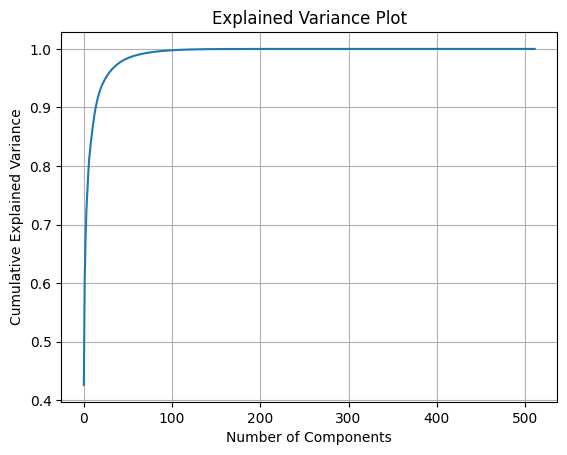

In [15]:
explained_variance = eigenvalues / np.sum(eigenvalues)

plt.plot(np.cumsum(explained_variance))
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Explained Variance Plot")
plt.grid()
plt.show()

3 Reconstruction and Experiment:

Experiment with 4 Different Components

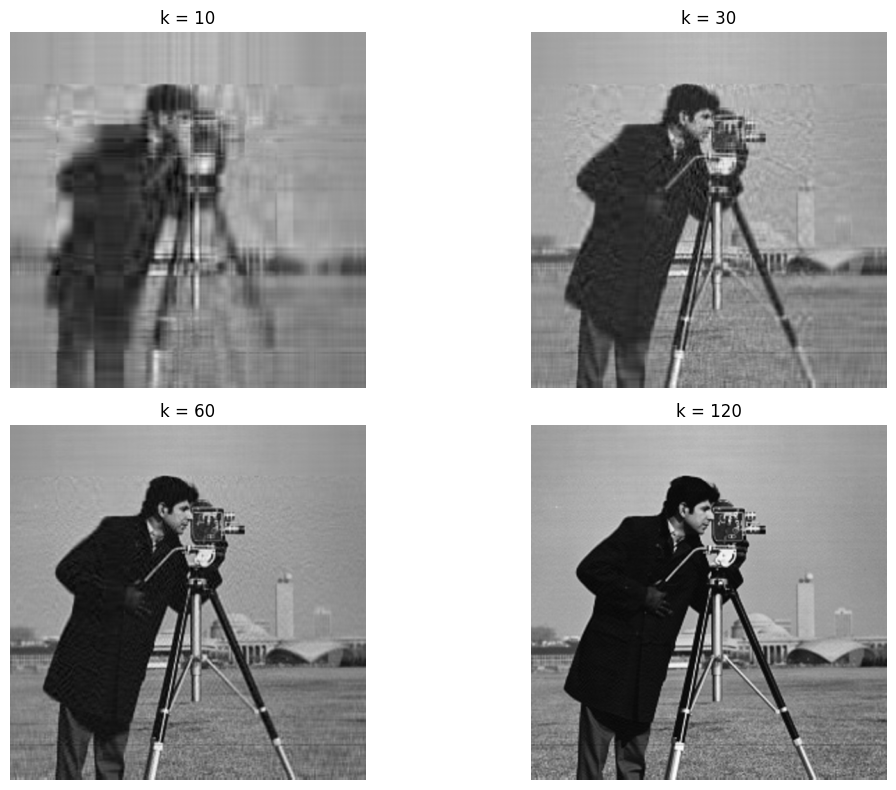

In [16]:
components_list = [10, 30, 60, 120]

plt.figure(figsize=(12,8))

for i,k in enumerate(components_list):

    components = eigenvectors[:,:k]

    compressed = np.dot(centered_data, components)

    reconstructed = np.dot(compressed, components.T) + mean

    plt.subplot(2,2,i+1)
    plt.imshow(reconstructed, cmap="gray")
    plt.title(f"k = {k}")
    plt.axis("off")

plt.tight_layout()
plt.show()